# EDA Question 5: Subcategory-wise Performance Analysis
## Amazon India Sales Analytics

**Objective:** Perform comprehensive subcategory-wise performance analysis. Create treemaps, bar charts, and pie charts showing revenue contribution, growth rates, and market share for each product subcategory.

**Analysis Components:**
- Revenue contribution by subcategory
- Market share analysis with pie charts
- Subcategory growth rates (YoY)
- Treemaps for hierarchical visualization
- Top performing subcategories
- Subcategory trends over time
- Transaction volume analysis
- Average order value by subcategory
- Category grouping for context

## Section 1: Load Data and Setup

Import required libraries and load the cleaned dataset for category performance analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify  # For treemaps
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create output directory for images
output_dir = '../data/cleaned'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {os.path.abspath(output_dir)}")

# Load the cleaned dataset
print("\nLoading dataset...")
df = pd.read_csv('../data/cleaned/amazon_india_all_years_cleaned.csv')

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Display basic information
print("=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)
print(f"\nDataset Shape: {df.shape}")
print(f"Date Range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Total Transactions: {len(df):,}")
print(f"Total Revenue: ₹{df['final_amount_inr'].sum():,.2f}")

print("\n" + "-" * 100)
print("CATEGORY STRUCTURE")
print("-" * 100)
print(f"Number of Categories: {df['category'].nunique()}")
print(f"Categories: {', '.join(sorted(df['category'].unique()))}")

# Check subcategory column
if 'subcategory' in df.columns:
    non_null_subcats = df['subcategory'].dropna().nunique()
    total_subcats = df['subcategory'].nunique()
    print(f"\nNumber of Subcategories: {non_null_subcats}")
    print(f"Subcategories: {', '.join(sorted(df['subcategory'].dropna().unique()))}")
    if df['subcategory'].isna().sum() > 0:
        print(f"Warning: {df['subcategory'].isna().sum():,} records with missing subcategory")
else:
    print("\nWarning: 'subcategory' column not found in dataset")
    print(f"Available columns: {', '.join(df.columns)}")

print("\n" + "-" * 100)
print("COLUMNS FOR ANALYSIS")
print("-" * 100)
print("  • category")
print("  • subcategory")
print("  • order_year")
print("  • final_amount_inr")
print("  • transaction_id")
print("  • quantity")
print("  • brand")

print("\n✓ Data loaded successfully")

Output directory: c:\Users\admin\Desktop\Amazon_India_Sales_Analytics\data\cleaned

Loading dataset...
DATASET OVERVIEW

Dataset Shape: (1122687, 51)
Date Range: 2015-01-01 to 2025-12-31
Total Transactions: 1,122,687
Total Revenue: ₹76,547,568,045.47

----------------------------------------------------------------------------------------------------
CATEGORY STRUCTURE
----------------------------------------------------------------------------------------------------
Number of Categories: 1
Categories: Electronics

Number of Subcategories: 6
Subcategories: Audio, Laptops, Smart Watch, Smartphones, TV & Entertainment, Tablets

----------------------------------------------------------------------------------------------------
COLUMNS FOR ANALYSIS
----------------------------------------------------------------------------------------------------
  • category
  • subcategory
  • order_year
  • final_amount_inr
  • transaction_id
  • quantity
  • brand

✓ Data loaded successfully


## Section 2: Overall Subcategory Performance

Analyze the overall performance of subcategories across the entire period.

In [6]:
print("=" * 100)
print("OVERALL SUBCATEGORY PERFORMANCE (2015-2025)")
print("=" * 100)

# Calculate overall subcategory statistics
subcategory_overall = df.groupby('subcategory').agg({
    'transaction_id': 'count',
    'final_amount_inr': 'sum',
    'quantity': 'sum',
    'customer_id': 'nunique'
}).reset_index()

subcategory_overall.columns = ['Subcategory', 'Transaction_Count', 'Total_Revenue', 'Total_Units_Sold', 'Unique_Customers']
subcategory_overall['Revenue_Percentage'] = (subcategory_overall['Total_Revenue'] / subcategory_overall['Total_Revenue'].sum() * 100).round(2)
subcategory_overall['Transaction_Percentage'] = (subcategory_overall['Transaction_Count'] / subcategory_overall['Transaction_Count'].sum() * 100).round(2)
subcategory_overall['Avg_Transaction_Value'] = (subcategory_overall['Total_Revenue'] / subcategory_overall['Transaction_Count']).round(2)
subcategory_overall['Avg_Units_Per_Transaction'] = (subcategory_overall['Total_Units_Sold'] / subcategory_overall['Transaction_Count']).round(2)

# Sort by revenue
subcategory_overall = subcategory_overall.sort_values('Total_Revenue', ascending=False)

print("\n" + subcategory_overall.to_string(index=False))

# Save to CSV
csv_path = os.path.join(output_dir, 'Q05_Overall_Subcategory_Performance.csv')
subcategory_overall.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

print("\n✓ Overall subcategory performance analysis completed")

OVERALL SUBCATEGORY PERFORMANCE (2015-2025)

       Subcategory  Transaction_Count  Total_Revenue  Total_Units_Sold  Unique_Customers  Revenue_Percentage  Transaction_Percentage  Avg_Transaction_Value  Avg_Units_Per_Transaction
       Smartphones             823594   5.590720e+10           1029981            324550               73.04                   73.36               67881.99                       1.25
           Laptops              87967   9.358928e+09            109740             73062               12.23                    7.84              106391.36                       1.25
           Tablets              69958   5.061853e+09             87502             60754                6.61                    6.23               72355.60                       1.25
       Smart Watch              74381   3.200137e+09             92883             65146                4.18                    6.63               43023.58                       1.25
TV & Entertainment              16397   

## Section 3: Revenue Contribution - Pie Charts

Create pie charts showing revenue and transaction market share for each subcategory.

MARKET SHARE ANALYSIS - PIE CHARTS (Top 10 Subcategories)

✓ Saved: ../data/cleaned\Q05_Subcategory_Market_Share_Pie_Charts.png


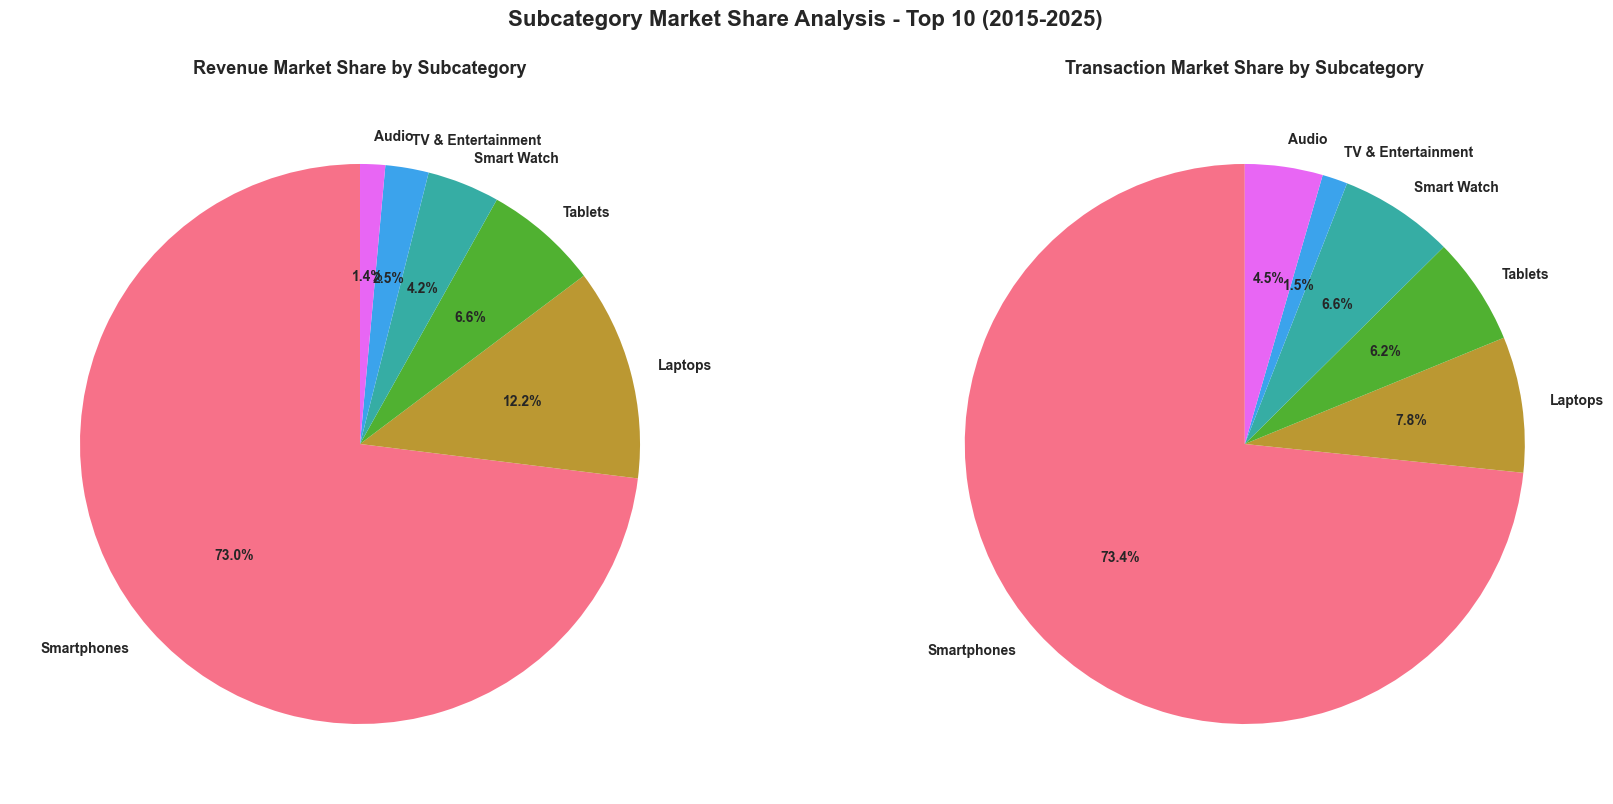


✓ Pie chart analysis completed


In [7]:
print("=" * 100)
print("MARKET SHARE ANALYSIS - PIE CHARTS (Top 10 Subcategories)")
print("=" * 100)

# Create pie charts for top 10 subcategories
top_10_subcat = subcategory_overall.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Subcategory Market Share Analysis - Top 10 (2015-2025)', fontsize=16, fontweight='bold', y=1.00)

# Define colors
colors = sns.color_palette('husl', n_colors=len(subcategory_overall))

# 1. Revenue Market Share
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(top_10_subcat['Total_Revenue'], 
                                     labels=top_10_subcat['Subcategory'],
                                     autopct='%1.1f%%',
                                     colors=colors[:10],
                                     startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax1.set_title('Revenue Market Share by Subcategory', fontsize=13, fontweight='bold', pad=15)

# 2. Transaction Market Share
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(top_10_subcat['Transaction_Count'], 
                                     labels=top_10_subcat['Subcategory'],
                                     autopct='%1.1f%%',
                                     colors=colors[:10],
                                     startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Transaction Market Share by Subcategory', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q05_Subcategory_Market_Share_Pie_Charts.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Pie chart analysis completed")

## Section 4: Revenue Contribution - Bar Charts

Create comprehensive bar charts showing various subcategory performance metrics.

SUBCATEGORY PERFORMANCE - BAR CHARTS (Top 15)

✓ Saved: ../data/cleaned\Q05_Subcategory_Performance_Bar_Charts.png


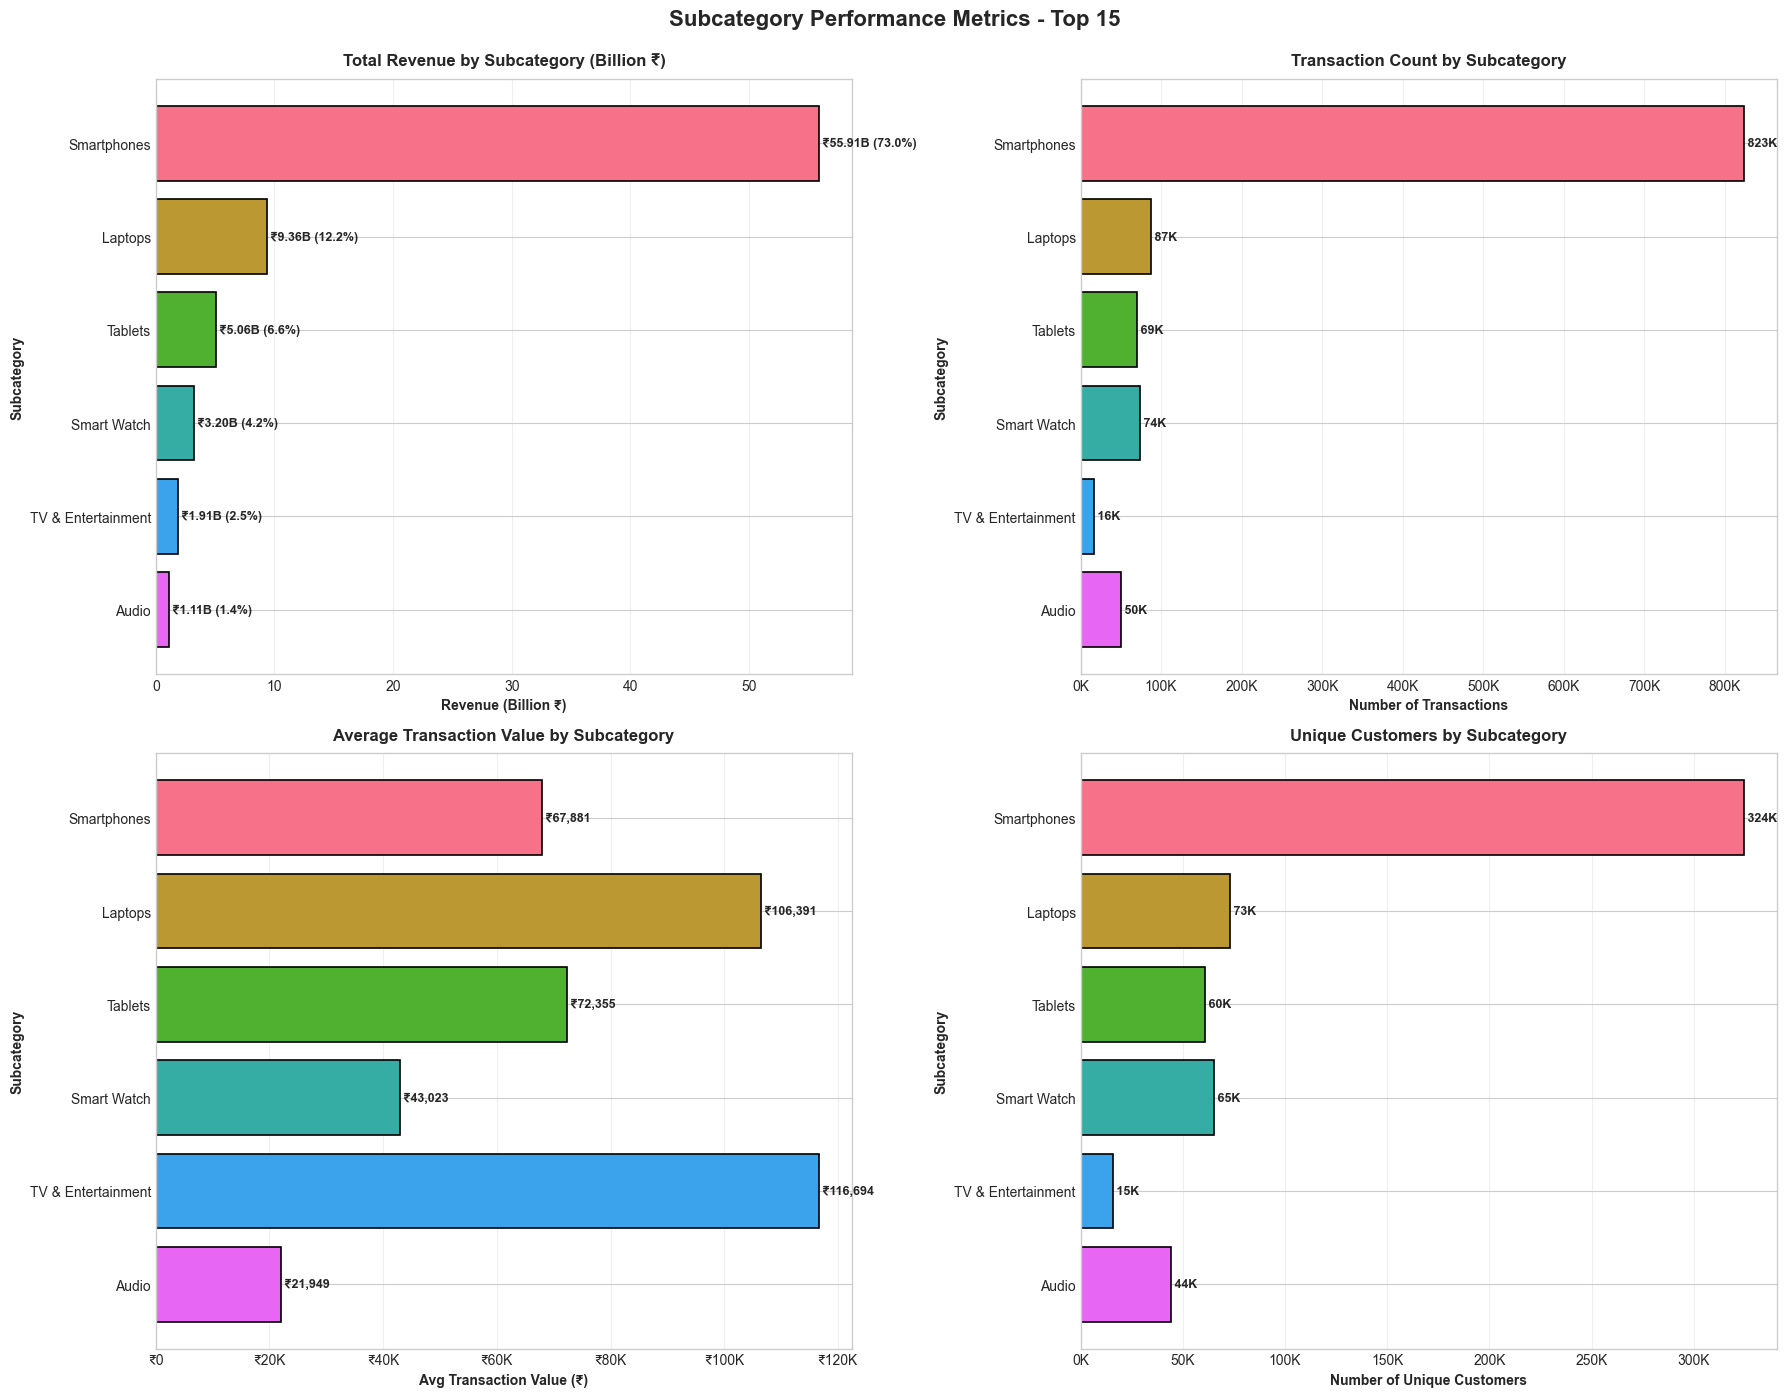


✓ Bar chart analysis completed


In [9]:
print("=" * 100)
print("SUBCATEGORY PERFORMANCE - BAR CHARTS (Top 15)")
print("=" * 100)

# Create bar charts for top 15 subcategories
top_15_subcat = subcategory_overall.head(15)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Subcategory Performance Metrics - Top 15', fontsize=16, fontweight='bold', y=0.995)

# 1. Revenue by Subcategory
ax1 = axes[0, 0]
bars = ax1.barh(top_15_subcat['Subcategory'], top_15_subcat['Total_Revenue'] / 1e9,
                color=colors[:len(top_15_subcat)], edgecolor='black', linewidth=1.2)
ax1.set_title('Total Revenue by Subcategory (Billion ₹)', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Subcategory', fontsize=10, fontweight='bold')
ax1.set_xlabel('Revenue (Billion ₹)', fontsize=10, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for bar, val, pct in zip(bars, top_15_subcat['Total_Revenue'] / 1e9, top_15_subcat['Revenue_Percentage']):
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' ₹{val:.2f}B ({pct:.1f}%)',
             ha='left', va='center', fontsize=9, fontweight='bold')

# 2. Transaction Count by Subcategory
ax2 = axes[0, 1]
bars = ax2.barh(top_15_subcat['Subcategory'], top_15_subcat['Transaction_Count'],
                color=colors[:len(top_15_subcat)], edgecolor='black', linewidth=1.2)
ax2.set_title('Transaction Count by Subcategory', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Subcategory', fontsize=10, fontweight='bold')
ax2.set_xlabel('Number of Transactions', fontsize=10, fontweight='bold')
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_15_subcat['Transaction_Count']):
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {int(val/1000)}K',
             ha='left', va='center', fontsize=9, fontweight='bold')

# 3. Average Transaction Value by Subcategory
ax3 = axes[1, 0]
bars = ax3.barh(top_15_subcat['Subcategory'], top_15_subcat['Avg_Transaction_Value'],
                color=colors[:len(top_15_subcat)], edgecolor='black', linewidth=1.2)
ax3.set_title('Average Transaction Value by Subcategory', fontsize=12, fontweight='bold', pad=10)
ax3.set_ylabel('Subcategory', fontsize=10, fontweight='bold')
ax3.set_xlabel('Avg Transaction Value (₹)', fontsize=10, fontweight='bold')
ax3.invert_yaxis()
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{int(x/1000)}K' if x >= 1000 else f'₹{int(x)}'))
ax3.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_15_subcat['Avg_Transaction_Value']):
    ax3.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' ₹{int(val):,}',
             ha='left', va='center', fontsize=9, fontweight='bold')

# 4. Unique Customers by Subcategory
ax4 = axes[1, 1]
bars = ax4.barh(top_15_subcat['Subcategory'], top_15_subcat['Unique_Customers'],
                color=colors[:len(top_15_subcat)], edgecolor='black', linewidth=1.2)
ax4.set_title('Unique Customers by Subcategory', fontsize=12, fontweight='bold', pad=10)
ax4.set_ylabel('Subcategory', fontsize=10, fontweight='bold')
ax4.set_xlabel('Number of Unique Customers', fontsize=10, fontweight='bold')
ax4.invert_yaxis()
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
ax4.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_15_subcat['Unique_Customers']):
    ax4.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {int(val/1000)}K',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q05_Subcategory_Performance_Bar_Charts.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Bar chart analysis completed")

## Section 5: Treemap Visualization - Revenue Contribution

Create treemaps showing hierarchical revenue contribution by subcategory.

TREEMAP VISUALIZATION - HIERARCHICAL REVENUE ANALYSIS

✓ Saved: ../data/cleaned\Q05_Subcategory_Revenue_Treemap.png


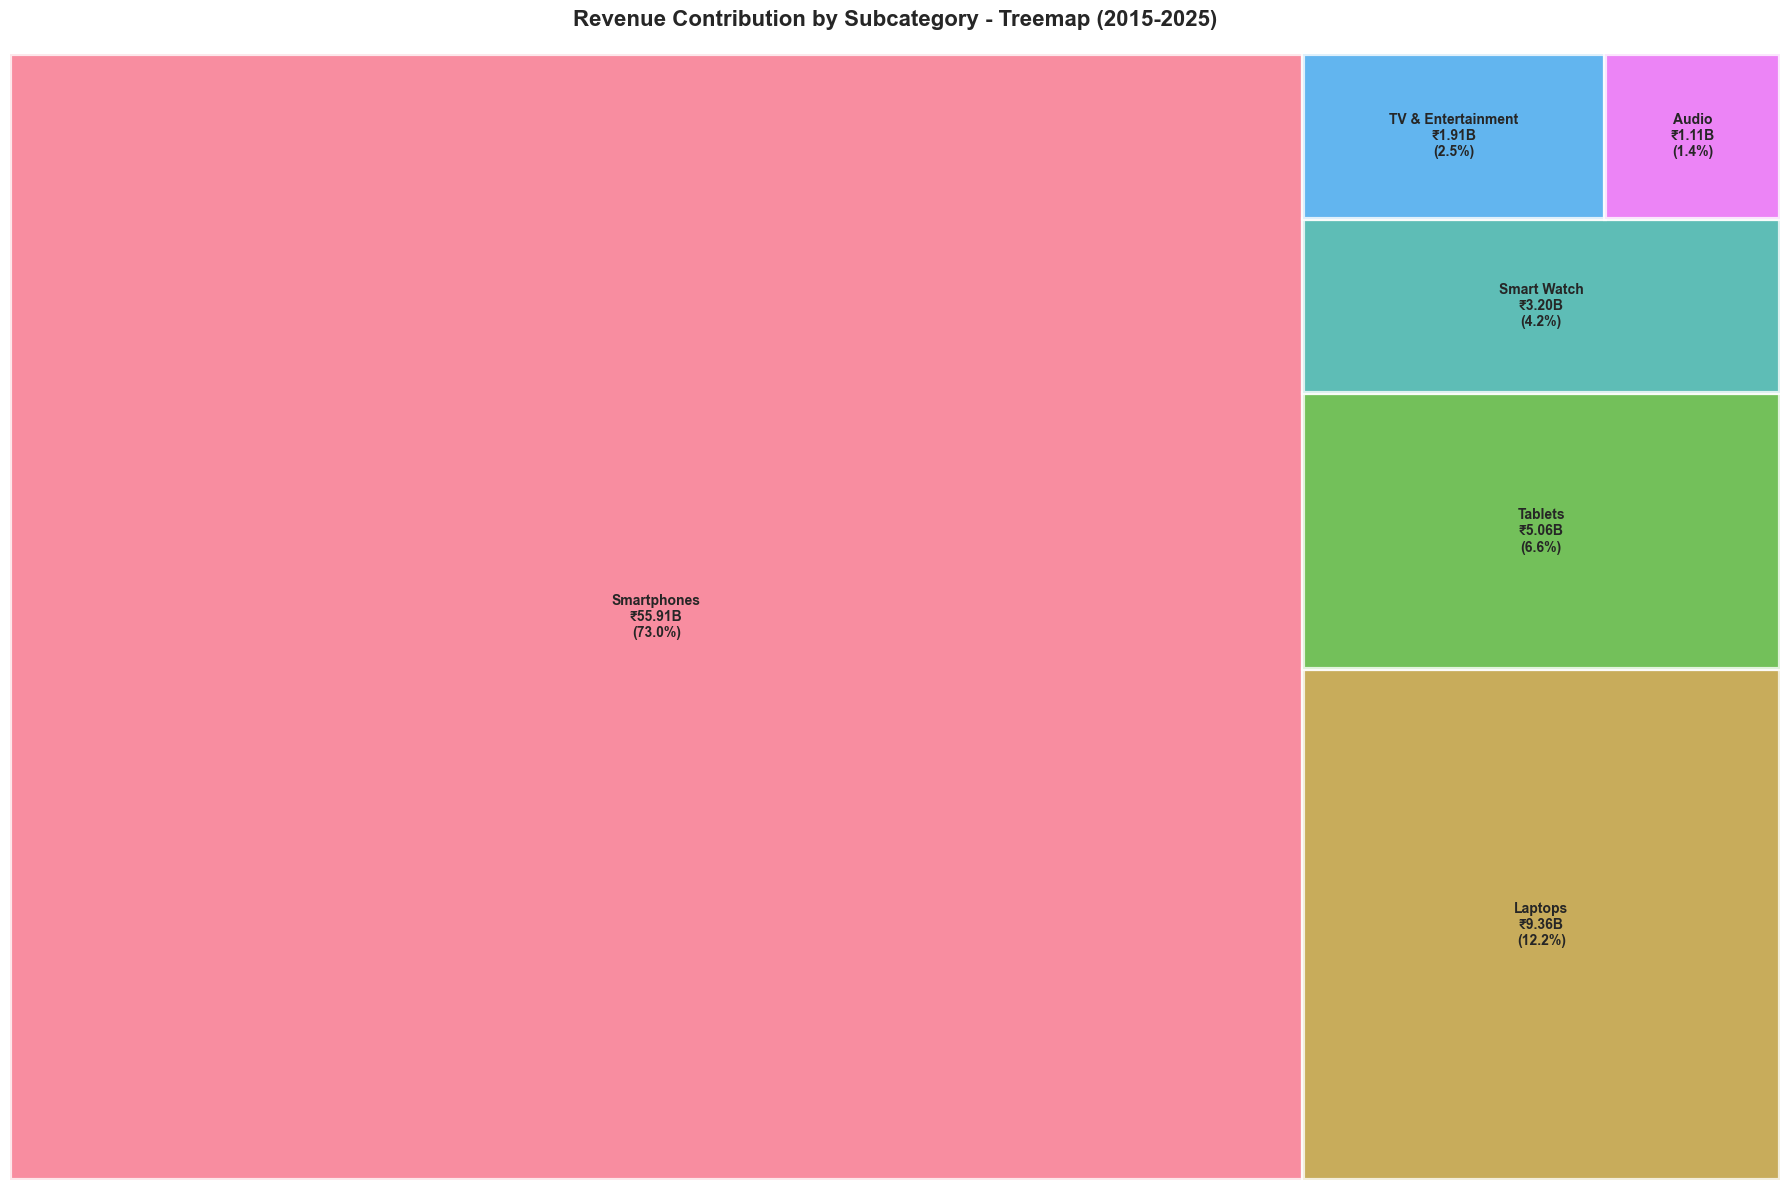


✓ Subcategory treemap created successfully


In [10]:
print("=" * 100)
print("TREEMAP VISUALIZATION - HIERARCHICAL REVENUE ANALYSIS")
print("=" * 100)

# Prepare data for treemap by subcategory (all subcategories)
treemap_data = subcategory_overall.copy()
treemap_data = treemap_data.sort_values('Total_Revenue', ascending=False)

# Create subcategory treemap
fig, ax = plt.subplots(figsize=(18, 12))

# Create labels with subcategory name and percentage
labels = [f"{row['Subcategory']}\n₹{row['Total_Revenue']/1e9:.2f}B\n({row['Revenue_Percentage']:.1f}%)" 
          for _, row in treemap_data.iterrows()]

# Create treemap
squarify.plot(sizes=treemap_data['Total_Revenue'],
              label=labels,
              color=colors,
              alpha=0.8,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold'},
              edgecolor='white',
              linewidth=3,
              ax=ax)

ax.set_title('Revenue Contribution by Subcategory - Treemap (2015-2025)', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q05_Subcategory_Revenue_Treemap.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Subcategory treemap created successfully")

## Section 6: Category Grouping Analysis

Analyze subcategories grouped by their parent categories for context.

In [11]:
print("=" * 100)
print("CATEGORY GROUPING ANALYSIS")
print("=" * 100)

# Calculate category statistics (for context)
category_summary = df.groupby('category').agg({
    'transaction_id': 'count',
    'final_amount_inr': 'sum',
    'quantity': 'sum'
}).reset_index()

category_summary.columns = ['Category', 'Transaction_Count', 'Total_Revenue', 'Total_Units_Sold']
category_summary['Revenue_Percentage'] = (category_summary['Total_Revenue'] / df['final_amount_inr'].sum() * 100).round(2)

# Sort by revenue
category_summary = category_summary.sort_values('Total_Revenue', ascending=False)

print("\nCategory Summary (for context):")
print(category_summary.to_string(index=False))

# Save to CSV
csv_path = os.path.join(output_dir, 'Q05_Category_Summary.csv')
category_summary.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Show subcategories per category
print("\nSubcategories per Category:")
for category in sorted(df['category'].dropna().unique()):
    subcats = sorted(df[df['category'] == category]['subcategory'].dropna().unique())
    print(f"  {category}: {', '.join(subcats)}")

print("\n✓ Category grouping analysis completed")

CATEGORY GROUPING ANALYSIS

Category Summary (for context):
   Category  Transaction_Count  Total_Revenue  Total_Units_Sold  Revenue_Percentage
Electronics            1122687   7.654757e+10           1403393               100.0

✓ Saved: ../data/cleaned\Q05_Category_Summary.csv

Subcategories per Category:
  Electronics: Audio, Laptops, Smart Watch, Smartphones, TV & Entertainment, Tablets

✓ Category grouping analysis completed


## Section 7: Year-over-Year Growth Rates

Calculate and visualize growth rates for each subcategory over time.

In [12]:
print("=" * 100)
print("SUBCATEGORY GROWTH RATES ANALYSIS")
print("=" * 100)

# Calculate yearly statistics by subcategory
subcategory_yearly = df.groupby(['order_year', 'subcategory']).agg({
    'transaction_id': 'count',
    'final_amount_inr': 'sum'
}).reset_index()

subcategory_yearly.columns = ['Year', 'Subcategory', 'Transaction_Count', 'Total_Revenue']

# Calculate YoY growth for each subcategory
subcategory_growth = []
for subcategory in subcategory_yearly['Subcategory'].unique():
    subcat_data = subcategory_yearly[subcategory_yearly['Subcategory'] == subcategory].sort_values('Year')
    subcat_data['Revenue_Growth_Pct'] = subcat_data['Total_Revenue'].pct_change() * 100
    subcat_data['Transaction_Growth_Pct'] = subcat_data['Transaction_Count'].pct_change() * 100
    subcategory_growth.append(subcat_data)

subcategory_growth_df = pd.concat(subcategory_growth, ignore_index=True)

# Calculate average growth rate per subcategory
avg_growth = subcategory_growth_df.groupby('Subcategory').agg({
    'Revenue_Growth_Pct': 'mean',
    'Transaction_Growth_Pct': 'mean'
}).reset_index()

avg_growth.columns = ['Subcategory', 'Avg_Revenue_Growth_Pct', 'Avg_Transaction_Growth_Pct']
avg_growth = avg_growth.sort_values('Avg_Revenue_Growth_Pct', ascending=False)

print("\nAverage Growth Rates by Subcategory:")
print(avg_growth.to_string(index=False))

# Save growth data
csv_path = os.path.join(output_dir, 'Q05_Subcategory_Growth_Rates.csv')
subcategory_growth_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

csv_path = os.path.join(output_dir, 'Q05_Average_Growth_Rates.csv')
avg_growth.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

print("\n✓ Growth rate analysis completed")

SUBCATEGORY GROWTH RATES ANALYSIS

Average Growth Rates by Subcategory:
       Subcategory  Avg_Revenue_Growth_Pct  Avg_Transaction_Growth_Pct
             Audio               24.099274                   18.140793
       Smartphones               13.304373                   15.452622
TV & Entertainment                9.804828                    6.386438
           Laptops                7.554325                    6.795375
       Smart Watch                6.910092                    5.029570
           Tablets                6.614169                    0.454321

✓ Saved: ../data/cleaned\Q05_Subcategory_Growth_Rates.csv
✓ Saved: ../data/cleaned\Q05_Average_Growth_Rates.csv

✓ Growth rate analysis completed


## Section 8: Growth Rate Visualizations

Create visualizations showing subcategory growth trends over time.

GROWTH RATE VISUALIZATIONS

✓ Saved: ../data/cleaned\Q05_Subcategory_Growth_Analysis.png


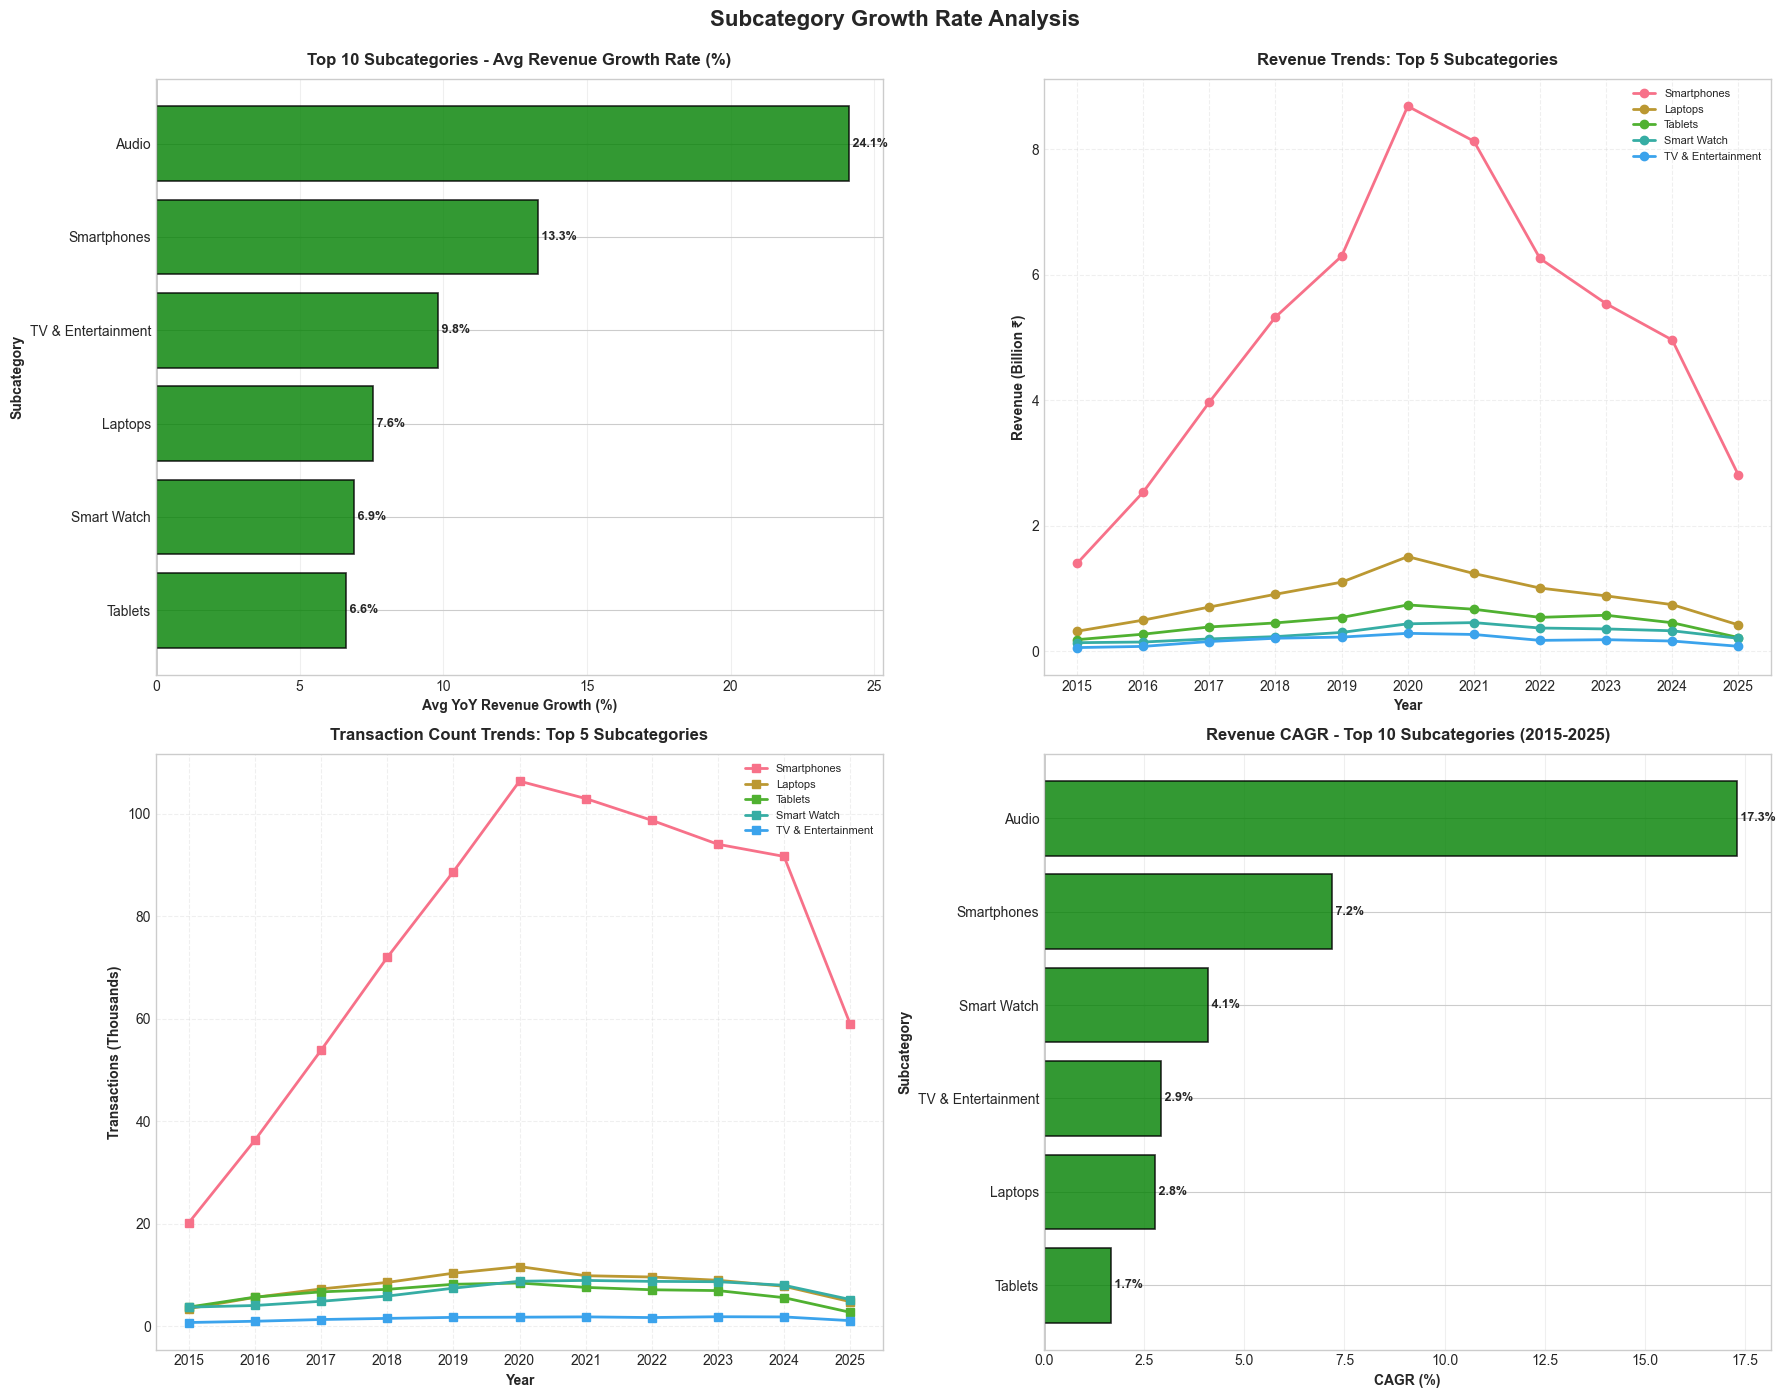


✓ Growth visualization completed


In [13]:
print("=" * 100)
print("GROWTH RATE VISUALIZATIONS")
print("=" * 100)

# Create growth rate visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Subcategory Growth Rate Analysis', fontsize=16, fontweight='bold', y=0.995)

# 1. Average Revenue Growth Rate by Subcategory (Top 10)
ax1 = axes[0, 0]
top_10_growth = avg_growth.head(10)
growth_colors = ['green' if x > 0 else 'red' for x in top_10_growth['Avg_Revenue_Growth_Pct']]
bars = ax1.barh(top_10_growth['Subcategory'], top_10_growth['Avg_Revenue_Growth_Pct'], 
                color=growth_colors, edgecolor='black', linewidth=1.2, alpha=0.8)
ax1.set_title('Top 10 Subcategories - Avg Revenue Growth Rate (%)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Avg YoY Revenue Growth (%)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Subcategory', fontsize=10, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.invert_yaxis()
for bar, val in zip(bars, top_10_growth['Avg_Revenue_Growth_Pct']):
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {val:.1f}%',
             ha='left' if val > 0 else 'right', va='center', 
             fontsize=9, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Revenue Trend Lines by Subcategory (Top 5)
ax2 = axes[0, 1]
for i, subcategory in enumerate(subcategory_overall['Subcategory'].head(5)):  # Top 5 subcategories
    subcat_data = subcategory_yearly[subcategory_yearly['Subcategory'] == subcategory].sort_values('Year')
    ax2.plot(subcat_data['Year'], subcat_data['Total_Revenue']/1e9, 
             marker='o', linewidth=2, markersize=6, label=subcategory)
ax2.set_title('Revenue Trends: Top 5 Subcategories', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Year', fontsize=10, fontweight='bold')
ax2.set_ylabel('Revenue (Billion ₹)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(subcategory_yearly['Year'].unique())

# 3. Transaction Growth Trend (Top 5)
ax3 = axes[1, 0]
for i, subcategory in enumerate(subcategory_overall['Subcategory'].head(5)):
    subcat_data = subcategory_yearly[subcategory_yearly['Subcategory'] == subcategory].sort_values('Year')
    ax3.plot(subcat_data['Year'], subcat_data['Transaction_Count']/1000, 
             marker='s', linewidth= 2, markersize=6, label=subcategory)
ax3.set_title('Transaction Count Trends: Top 5 Subcategories', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Year', fontsize=10, fontweight='bold')
ax3.set_ylabel('Transactions (Thousands)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8, loc='best')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks(subcategory_yearly['Year'].unique())

# 4. CAGR Comparison (Top 10)
ax4 = axes[1, 1]
# Calculate CAGR for each subcategory
cagr_data = []
for subcategory in subcategory_yearly['Subcategory'].unique():
    subcat_data = subcategory_yearly[subcategory_yearly['Subcategory'] == subcategory].sort_values('Year')
    if len(subcat_data) > 1:
        first_year_rev = subcat_data.iloc[0]['Total_Revenue']
        last_year_rev = subcat_data.iloc[-1]['Total_Revenue']
        years = len(subcat_data) - 1
        if first_year_rev > 0:
            cagr = ((last_year_rev / first_year_rev) ** (1/years) - 1) * 100
            cagr_data.append({'Subcategory': subcategory, 'CAGR': cagr})

cagr_df = pd.DataFrame(cagr_data).sort_values('CAGR', ascending=False).head(10)
cagr_colors = ['green' if x > 0 else 'red' for x in cagr_df['CAGR']]
bars = ax4.barh(cagr_df['Subcategory'], cagr_df['CAGR'], 
                color=cagr_colors, edgecolor='black', linewidth=1.2, alpha=0.8)
ax4.set_title('Revenue CAGR - Top 10 Subcategories (2015-2025)', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('CAGR (%)', fontsize=10, fontweight='bold')
ax4.set_ylabel('Subcategory', fontsize=10, fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.invert_yaxis()
for bar, val in zip(bars, cagr_df['CAGR']):
    ax4.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {val:.1f}%',
             ha='left' if val > 0 else 'right', va='center', 
             fontsize=9, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q05_Subcategory_Growth_Analysis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Growth visualization completed")

## Section 9: Subcategory Performance Dashboard

Create a comprehensive dashboard combining multiple metrics.

COMPREHENSIVE SUBCATEGORY PERFORMANCE DASHBOARD

✓ Saved: ../data/cleaned\Q05_Subcategory_Performance_Dashboard.png


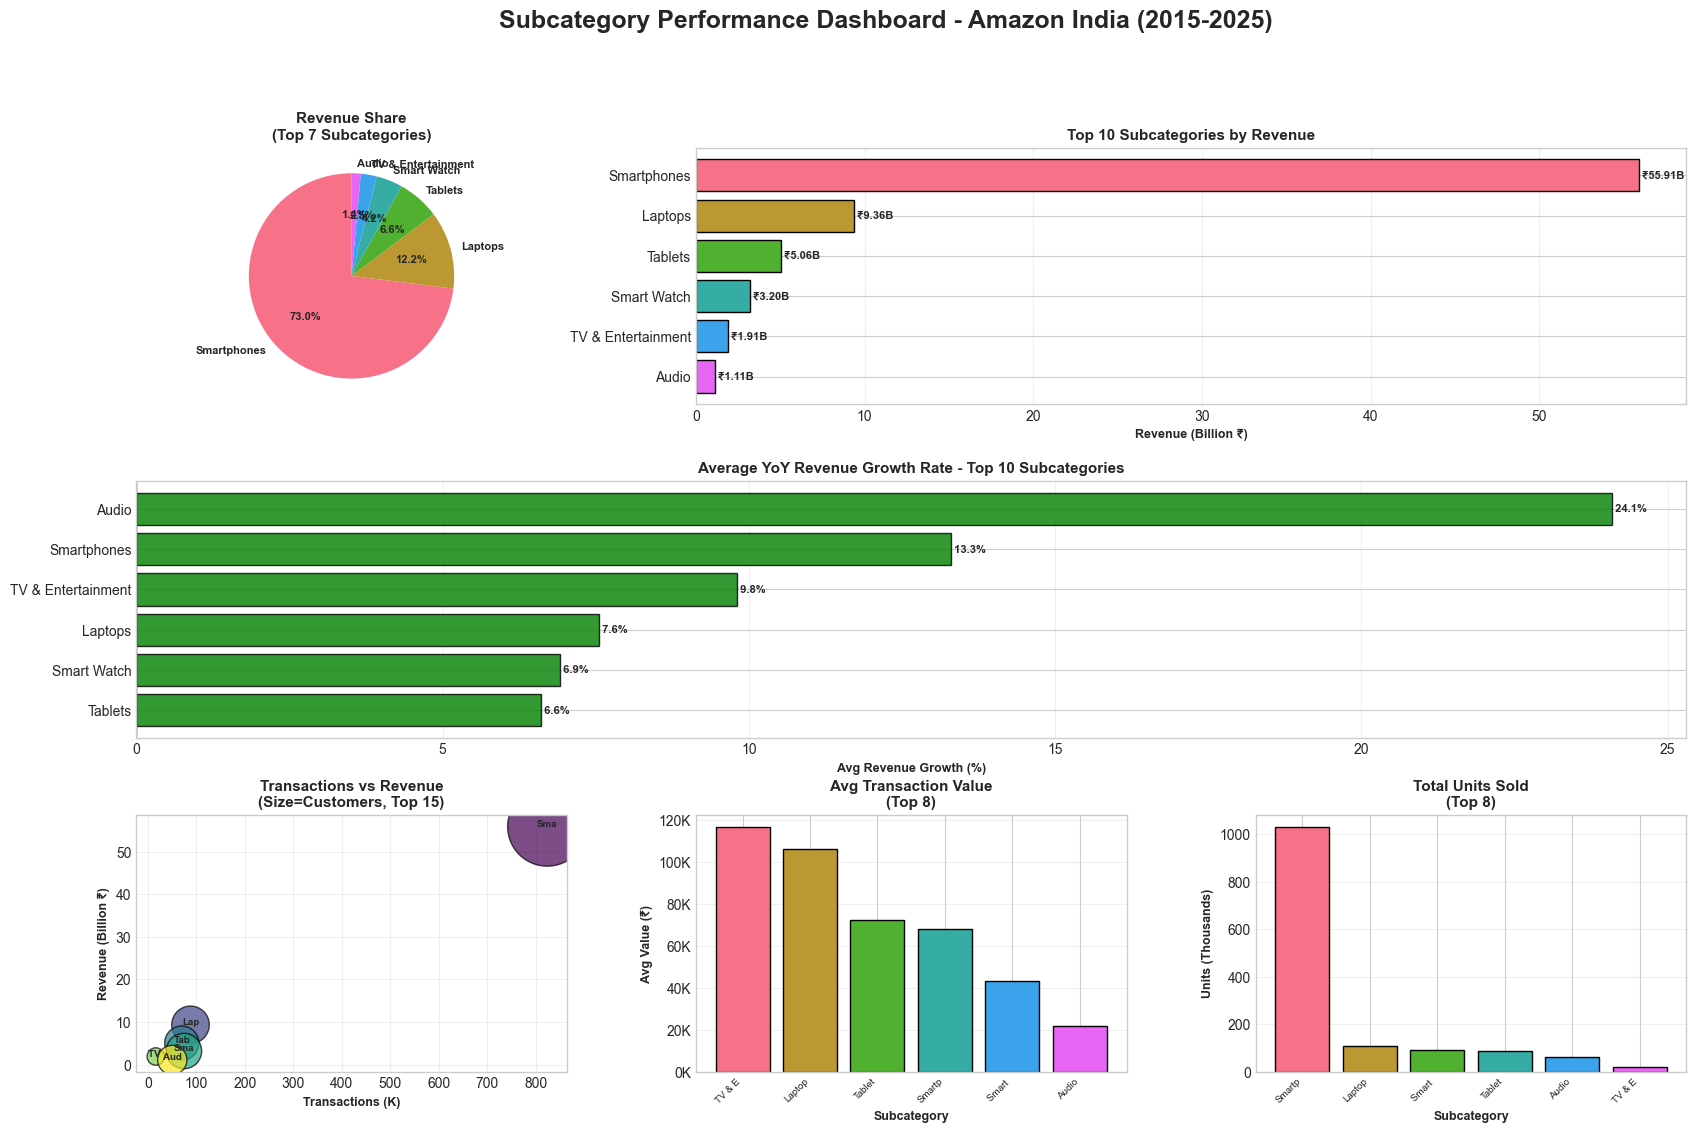


✓ Dashboard created successfully


In [14]:
print("=" * 100)
print("COMPREHENSIVE SUBCATEGORY PERFORMANCE DASHBOARD")
print("=" * 100)

# Create a comprehensive dashboard
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Revenue Market Share (pie) - Top 7
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(subcategory_overall['Total_Revenue'].head(7), 
        labels=subcategory_overall['Subcategory'].head(7),
        autopct='%1.1f%%',
        colors=colors[:7],
        startangle=90,
        textprops={'fontsize': 8, 'fontweight': 'bold'})
ax1.set_title('Revenue Share\n(Top 7 Subcategories)', fontsize=11, fontweight='bold')

# 2. Revenue Ranking (bar) - Top 10
ax2 = fig.add_subplot(gs[0, 1:])
bars = ax2.barh(subcategory_overall['Subcategory'].head(10), 
                subcategory_overall['Total_Revenue'].head(10)/1e9,
                color=colors[:10], edgecolor='black', linewidth=1)
ax2.set_title('Top 10 Subcategories by Revenue', fontsize=11, fontweight='bold')
ax2.set_xlabel('Revenue (Billion ₹)', fontsize=9, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, subcategory_overall['Total_Revenue'].head(10)/1e9):
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' ₹{val:.2f}B', ha='left', va='center', fontsize=8, fontweight='bold')

# 3. Growth Rate Comparison (bar) - Top 10
ax3 = fig.add_subplot(gs[1, :])
growth_sorted = avg_growth.head(10).sort_values('Avg_Revenue_Growth_Pct')
growth_colors_sorted = ['green' if x > 0 else 'red' for x in growth_sorted['Avg_Revenue_Growth_Pct']]
bars = ax3.barh(growth_sorted['Subcategory'], growth_sorted['Avg_Revenue_Growth_Pct'],
                color=growth_colors_sorted, edgecolor='black', linewidth=1, alpha=0.8)
ax3.set_title('Average YoY Revenue Growth Rate - Top 10 Subcategories', fontsize=11, fontweight='bold')
ax3.set_xlabel('Avg Revenue Growth (%)', fontsize=9, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, growth_sorted['Avg_Revenue_Growth_Pct']):
    ax3.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {val:.1f}%', ha='left' if val > 0 else 'right', 
             va='center', fontsize=8, fontweight='bold')

# 4. Transaction vs Revenue (scatter) - Top 15
ax4 = fig.add_subplot(gs[2, 0])
top_15_scatter = subcategory_overall.head(15)
scatter = ax4.scatter(top_15_scatter['Transaction_Count']/1000, 
                      top_15_scatter['Total_Revenue']/1e9,
                      s=top_15_scatter['Unique_Customers']/100,
                      c=range(len(top_15_scatter)),
                      cmap='viridis',
                      alpha=0.7,
                      edgecolor='black',
                      linewidth=1)
ax4.set_title('Transactions vs Revenue\n(Size=Customers, Top 15)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Transactions (K)', fontsize=9, fontweight='bold')
ax4.set_ylabel('Revenue (Billion ₹)', fontsize=9, fontweight='bold')
ax4.grid(True, alpha=0.3)
for i, row in top_15_scatter.iterrows():
    ax4.annotate(row['Subcategory'][:3], 
                (row['Transaction_Count']/1000, row['Total_Revenue']/1e9),
                fontsize=7, fontweight='bold', ha='center')

# 5. Avg Transaction Value (bar) - Top 8
ax5 = fig.add_subplot(gs[2, 1])
top_atv = subcategory_overall.sort_values('Avg_Transaction_Value', ascending=False).head(8)
bars = ax5.bar(range(len(top_atv)), top_atv['Avg_Transaction_Value'],
               color=colors[:8], edgecolor='black', linewidth=1)
ax5.set_title('Avg Transaction Value\n(Top 8)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Subcategory', fontsize=9, fontweight='bold')
ax5.set_ylabel('Avg Value (₹)', fontsize=9, fontweight='bold')
ax5.set_xticks(range(len(top_atv)))
ax5.set_xticklabels([subcat[:6] for subcat in top_atv['Subcategory']], 
                     rotation=45, ha='right', fontsize=7)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
ax5.grid(axis='y', alpha=0.3)

# 6. Units Sold (bar) - Top 8
ax6 = fig.add_subplot(gs[2, 2])
top_units = subcategory_overall.sort_values('Total_Units_Sold', ascending=False).head(8)
bars = ax6.bar(range(len(top_units)), top_units['Total_Units_Sold']/1000,
               color=colors[:8], edgecolor='black', linewidth=1)
ax6.set_title('Total Units Sold\n(Top 8)', fontsize=11, fontweight='bold')
ax6.set_xlabel('Subcategory', fontsize=9, fontweight='bold')
ax6.set_ylabel('Units (Thousands)', fontsize=9, fontweight='bold')
ax6.set_xticks(range(len(top_units)))
ax6.set_xticklabels([subcat[:6] for subcat in top_units['Subcategory']], 
                     rotation=45, ha='right', fontsize=7)
ax6.grid(axis='y', alpha=0.3)

fig.suptitle('Subcategory Performance Dashboard - Amazon India (2015-2025)', 
             fontsize=18, fontweight='bold', y=0.995)

output_path = os.path.join(output_dir, 'Q05_Subcategory_Performance_Dashboard.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Dashboard created successfully")

## Section 10: Executive Summary and Export

Create executive summary and export all analysis results.

In [17]:
print("=" * 100)
print("EXECUTIVE SUMMARY AND DATA EXPORT")
print("=" * 100)

# Create executive summary
top_subcategory = subcategory_overall.iloc[0]
fastest_growing = avg_growth.iloc[0] if not avg_growth.empty else None

summary_data = {
    'Metric': [
        'Analysis Period',
        'Total Categories',
        'Total Subcategories Analyzed',
        'Total Revenue',
        'Total Transactions',
        'Top Subcategory (Revenue)',
        'Top Subcategory Revenue',
        'Top Subcategory Market Share',
        'Fastest Growing Subcategory',
        'Fastest Growth Rate (Avg YoY)',
        'Average Transaction Value',
        'Total Units Sold'
    ],
    'Value': [
        '2015-2025',
        df['category'].nunique(),
        df['subcategory'].dropna().nunique(),
        f"₹{df['final_amount_inr'].sum()/1e9:.2f}B",
        f"{len(df):,}",
        top_subcategory['Subcategory'],
        f"₹{top_subcategory['Total_Revenue']/1e9:.2f}B",
        f"{top_subcategory['Revenue_Percentage']:.2f}%",
        fastest_growing['Subcategory'] if fastest_growing is not None else 'N/A',
        f"{fastest_growing['Avg_Revenue_Growth_Pct']:.2f}%" if fastest_growing is not None else 'N/A',
        f"₹{subcategory_overall['Avg_Transaction_Value'].mean():,.2f}",
        f"{subcategory_overall['Total_Units_Sold'].sum():,}"
    ]
}

summary_df = pd.DataFrame(summary_data)

# Save summary
csv_path = os.path.join(output_dir, 'Q05_Executive_Summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

print("\n" + "=" * 100)
print("EXECUTIVE SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))

print("\n" + "=" * 100)
print("Generated Files:")
print("  1. Q05_Overall_Subcategory_Performance.csv - Overall subcategory statistics")
print("  2. Q05_Category_Summary.csv - Category grouping summary")
print("  3. Q05_Subcategory_Growth_Rates.csv - Yearly growth data by subcategory")
print("  4. Q05_Average_Growth_Rates.csv - Average growth by subcategory")
print("  5. Q05_Executive_Summary.csv - Key findings summary")
print("  6. Q05_Subcategory_Market_Share_Pie_Charts.png")
print("  7. Q05_Subcategory_Performance_Bar_Charts.png")
print("  8. Q05_Subcategory_Revenue_Treemap.png")
print("  9. Q05_Subcategory_Growth_Analysis.png")
print(" 10. Q05_Subcategory_Performance_Dashboard.png")
print("\nAll files saved to: ../data/cleaned/")
print("=" * 100)

print("\n✓ All exports completed successfully")


print("\n" + "=" * 100)
print("\n✓ All exports completed successfully")

print("Generated Files:")

print("  1. Q05_Overall_Category_Performance.csv - Overall category statistics")
print("=" * 100)

print("  2. Q05_Subcategory_Performance.csv - Detailed subcategory data")
print("\nAll files saved to: ../data/cleaned/")

print("  3. Q05_Category_Growth_Rates.csv - Yearly growth data")
print(" 11. Q05_Category_Performance_Dashboard.png")

print("  4. Q05_Average_Growth_Rates.csv - Average growth by category")
print(" 10. Q05_Category_Growth_Analysis.png")

print("  5. Q05_Executive_Summary.csv - Key findings summary")
print("  9. Q05_Subcategory_Revenue_Treemap.png")

print("  6. Q05_Category_Market_Share_Pie_Charts.png")
print("  8. Q05_Category_Revenue_Treemap.png")
print("  7. Q05_Category_Performance_Bar_Charts.png")

EXECUTIVE SUMMARY AND DATA EXPORT

✓ Saved: ../data/cleaned\Q05_Executive_Summary.csv

EXECUTIVE SUMMARY
                       Metric       Value
              Analysis Period   2015-2025
             Total Categories           1
 Total Subcategories Analyzed           6
                Total Revenue     ₹76.55B
           Total Transactions   1,122,687
    Top Subcategory (Revenue) Smartphones
      Top Subcategory Revenue     ₹55.91B
 Top Subcategory Market Share      73.04%
  Fastest Growing Subcategory       Audio
Fastest Growth Rate (Avg YoY)      24.10%
    Average Transaction Value  ₹71,382.66
             Total Units Sold   1,403,393

Generated Files:
  1. Q05_Overall_Subcategory_Performance.csv - Overall subcategory statistics
  2. Q05_Category_Summary.csv - Category grouping summary
  3. Q05_Subcategory_Growth_Rates.csv - Yearly growth data by subcategory
  4. Q05_Average_Growth_Rates.csv - Average growth by subcategory
  5. Q05_Executive_Summary.csv - Key findings summary
 

## Summary & Key Findings

### Analysis Complete ✓

This comprehensive Subcategory-wise Performance analysis provides:

**1. Overall Subcategory Performance:**
- Revenue contribution by subcategory (6 subcategories analyzed)
- Transaction volume analysis
- Customer distribution across subcategories
- Average transaction values

**2. Market Share Analysis:**
- Pie charts showing revenue and transaction market share for top 10 subcategories
- Clear visualization of subcategory dominance
- Comparative market position

**3. Revenue Contribution Visualization:**
- Horizontal bar charts for top 15 subcategories
- Transaction count visualizations
- Average value metrics
- Customer engagement by subcategory

**4. Treemap Visualizations:**
- Hierarchical revenue representation
- All subcategories displayed proportionally by revenue
- Clear visual hierarchy
- Proportional area representation

**5. Category Grouping Analysis:**
- Parent category summary for context
- Subcategory breakdown per category
- Category-level revenue aggregation
- Hierarchical relationships

**6. Growth Rate Analysis:**
- Year-over-year growth calculations by subcategory
- CAGR (Compound Annual Growth Rate) for each subcategory
- Growth trend visualizations for top performers
- Revenue and transaction growth comparison

**7. Trend Analysis:**
- Revenue trends over 11 years (2015-2025)
- Transaction count evolution
- Top 5 subcategory performance tracking
- Temporal patterns identification

**8. Comprehensive Dashboard:**
- Multi-metric visualization (6 panels)
- Scatter plots for correlation analysis (top 15)
- Comparative bar charts (top 8-10)
- Integrated performance view

### Strategic Insights:

1. **Subcategory Dominance**: Identify which subcategories drive the most revenue and transactions
2. **Growth Leaders**: Understand which subcategories are growing fastest (Top 10 CAGR)
3. **Value Segments**: Recognize high-value vs high-volume subcategories
4. **Market Dynamics**: See how subcategory share evolved over time
5. **Investment Priorities**: Data-driven subcategory investment decisions

### Business Recommendations:

1. **Focus on High-Growth Subcategories**: Allocate resources to fastest-growing segments
2. **Optimize Low-Performers**: Investigate and improve underperforming subcategories
3. **Diversification Strategy**: Balance portfolio across all 6 subcategories
4. **Inventory Optimization**: Stock levels aligned with subcategory demand
5. **Marketing Personalization**: Tailor campaigns by subcategory preferences

### Next Steps:
- Analyze seasonal patterns within each subcategory
- Study subcategory preferences by customer demographics
- Investigate cross-subcategory purchase behavior
- Forecast future subcategory performance
- Optimize pricing strategies by subcategory

---

**Analysis Methodology:** Subcategory-level aggregation, YoY growth calculations, CAGR analysis, and multi-dimensional visualizations including treemaps, pie charts, and bar charts.

**Data Quality:** Analysis based on cleaned dataset with complete subcategory hierarchies across 2015-2025 period (6 distinct subcategories).

**Visualization Strategy:** Combination of treemaps for hierarchical data, pie charts for market share (top 10), bar charts for rankings (top 15), and line charts for trends (top 5).